<a href="https://colab.research.google.com/github/deekshit-2007/machine-learning-/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean using numpy = 1560.6634538152612
Mean using my code = 1560.6634538152598

Variance using numpy = 58496.49239931618
Variance using my code = 58496.49239931618

Time for numpy mean = 3.868359999614768e-05
Time for my mean = 2.7044800003750424e-05

All mean = 1560.6634538152612
Wednesday mean = 1550.7060000000001
April mean = 1698.9526315789474

Probability of loss = 0.4979919678714859
Probability of profit and Wednesday = 0.08433734939759036
Probability of profit on Wednesday = 0.42


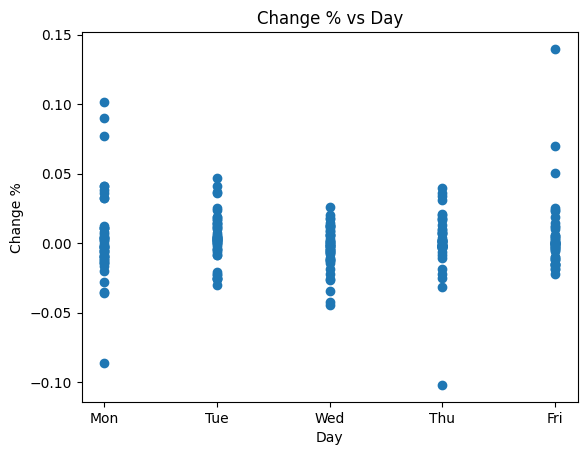

In [11]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
file = "Lab Session Data.xlsx"
def mean1(a):
    s = 0
    for i in a:
        s = s + i
    return s / len(a)
def var1(a):
    m = mean1(a)
    s = 0
    for i in a:
        s = s + (i - m) * (i - m)
    return s / len(a)
def find_time(fun, a):
    start = time.perf_counter()
    for i in range(10):
        fun(a)
    end = time.perf_counter()
    return (end - start) / 10
def loss(ch):
    c = 0
    for i in ch:
        if i < 0:
            c = c + 1
    return c / len(ch)
data = pd.read_excel(file, sheet_name="IRCTC Stock Price")
price = data["Price"]
chg = data["Chg%"]
print("Mean using numpy =", np.mean(price))
print("Mean using my code =", mean1(price))
print()
print("Variance using numpy =", np.var(price))
print("Variance using my code =", var1(price))
print()
print("Time for numpy mean =", find_time(np.mean, price))
print("Time for my mean =", find_time(mean1, price))
print()
all_mean = np.mean(price)
wed = data[data["Day"] == "Wed"]
wed_mean = np.mean(wed["Price"])
apr = data[data["Month"] == "Apr"]
apr_mean = np.mean(apr["Price"])
print("All mean =", all_mean)
print("Wednesday mean =", wed_mean)
print("April mean =", apr_mean)
print()
p_loss = loss(chg)
print("Probability of loss =", p_loss)
profit_wed = data[(data["Day"] == "Wed") & (data["Chg%"] > 0)]
p1 = len(profit_wed) / len(data)
print("Probability of profit and Wednesday =", p1)
p2 = len(profit_wed) / len(wed)
print("Probability of profit on Wednesday =", p2)
x = []
for i in data["Day"]:
    if i == "Mon":
        x.append(1)
    elif i == "Tue":
        x.append(2)
    elif i == "Wed":
        x.append(3)
    elif i == "Thu":
        x.append(4)
    elif i == "Fri":
        x.append(5)
plt.scatter(x, chg)
plt.xticks([1, 2, 3, 4, 5], ["Mon", "Tue", "Wed", "Thu", "Fri"])
plt.xlabel("Day")
plt.ylabel("Change %")
plt.title("Change % vs Day")
plt.show()

In [8]:
import pandas as pd
import numpy as np
FILE = "Lab Session Data.xlsx"
def value_to_number(v):
    if v in ("t", "F"):
        return 1.0
    if v in ("f", "M"):
        return 0.0
    if v == "?" or pd.isna(v):
        return 0.0
    try:
        return float(v)
    except (ValueError, TypeError):
        return 0.0
def row_to_vector(row, columns):
    return np.array([value_to_number(row[c]) for c in columns])
def cosine_similarity(a, b):
    dot = np.dot(a, b)
    return dot / (np.linalg.norm(a) * np.linalg.norm(b))
def main():
    df = pd.read_excel(FILE, sheet_name="thyroid0387_UCI")
    feature_columns = [c for c in df.columns if c not in ["Record ID", "referral source", "Condition"]]
    vector1 = row_to_vector(df.iloc[0], feature_columns)
    vector2 = row_to_vector(df.iloc[1], feature_columns)
    similarity = cosine_similarity(vector1, vector2)
    print("Vector 1:", vector1)
    print("Vector 2:", vector2)
    print("Cosine similarity:", similarity)
main()

Vector 1: [29.   1.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.
  0.   0.   1.   0.3  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
Vector 2: [ 29.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    1.    1.6   1.    1.9   1.  128.    0.    0.
   0.    0.    0.    0. ]
Cosine similarity: 0.22114270933028904


In [12]:
import pandas as pd
import numpy as np

file="Lab Session Data.xlsx"

def change(x):
    if x=="t" or x=="F":
        return 1
    elif x=="f" or x=="M":
        return 0
    elif x=="?" or pd.isna(x):
        return 0
    else:
        try:
            return float(x)
        except:
            return 0

data=pd.read_excel(file,sheet_name="thyroid0387_UCI")
col=[]
for i in data.columns:
    if i!="Record ID" and i!="referral source" and i!="Condition":
        col.append(i)
v1=[]
for i in col:
    v1.append(change(data.iloc[0][i]))
v2=[]
for i in col:
    v2.append(change(data.iloc[1][i]))
v1=np.array(v1)
v2=np.array(v2)
dot=np.dot(v1,v2)
n1=np.linalg.norm(v1)
n2=np.linalg.norm(v2)
ans=dot/(n1*n2)
print("Vector 1")
print(v1)
print()
print("Vector 2")
print(v2)
print()
print("Cosine Similarity =",ans)

Vector 1
[29.   1.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.
  0.   0.   1.   0.3  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]

Vector 2
[ 29.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    1.    1.6   1.    1.9   1.  128.    0.    0.
   0.    0.    0.    0. ]

Cosine Similarity = 0.22114270933028904


In [13]:
import pandas as pd
import numpy as np
file="Lab Session Data.xlsx"
def outlier(a):
    q1=a.quantile(0.25)
    q3=a.quantile(0.75)
    iqr=q3-q1
    low=q1-1.5*iqr
    high=q3+1.5*iqr
    x=a[(a<low) | (a>high)]
    if len(x)>0:
        return True
    else:
        return False
data=pd.read_excel(file,sheet_name="thyroid0387_UCI",na_values="?")
print("Missing values before")
print(data.isna().sum()[data.isna().sum()>0])
new=data.copy()
for i in new.columns:
    c=new[i]
    if c.isna().sum()==0:
        continue
    if pd.api.types.is_numeric_dtype(c):
        if outlier(c.dropna()):
            new[i]=c.fillna(c.median())
        else:
            new[i]=c.fillna(c.mean())
    else:
        new[i]=c.fillna(c.mode()[0])
print()
print("Missing values after")
print(new.isna().sum().sum())

Missing values before
sex     307
TSH     842
T3     2604
TT4     442
T4U     809
FTI     802
TBG    8823
dtype: int64

Missing values after
0
